# No Frames Attached

Companion notebook for the XRDS *Hello World* column
**"No Frames Attached: A Spiking Neural Network for Your Webcam."**

An event camera and a spiking neuron are built around the same idea:
integrate a signal, fire when it crosses a threshold. In this notebook
we connect them end-to-end in a short Python script: a webcam → a simulated
event stream → a Brian2 SNN → a plot showing that the network tracks
the motion in front of the camera while emitting a thousand times fewer
spikes than the sensor produced events.

Run top-to-bottom. Total wall time on a laptop: ~15 seconds after the
imports. To reproduce the column's figures exactly (no webcam needed),
run `uv run python make_figures.py` instead — it runs the same
pipeline on the bundled `wave.mp4` with a fixed seed.

**Setup** (skip if you already ran `uv sync` in this repo):

```bash
uv sync
uv run jupyter lab hello_spikes.ipynb
```

## Step 1 — Capture events from your webcam

Run the next cell and wave your hand across the frame for five
seconds. `eventify-dvs` turns each pair of frames into a stream of
*events*: tuples `(x, y, t, p)` for every pixel that changed by more
than `c_thresh` in log-intensity. Nothing dense past this point. That
sparsity is what a real silicon DVS pixel produces — its photocurrent
charges a capacitor whose voltage tracks log-intensity, and each
threshold crossing emits an event and resets. `eventify` is the same
integrate-and-fire circuit in software.

> **Tips:** to check your framing first, run `uv run eventify webcam`
> in a terminal (press `q` to quit) — it shows the live event stream.
> On macOS the first run prompts for camera permission; grant it,
> restart the kernel, and try again.

In [1]:
import numpy as np
from eventify import video_to_event_stream

SECONDS = 5
print(f"recording for {SECONDS} s — wave!")
events = np.concatenate(list(video_to_event_stream(
    1, c_thresh=0.15, sensor_size=(128, 128),
    duration_s=SECONDS, warmup_frames=10)))
print(f"{len(events):,} events over {events['t'].max() / 1e6:.2f} s")

recording for 5 s — wave!
209,094 events over 5.02 s


Sanity check: bin the event timestamps into 100 ms buckets and plot.
Each hump in this histogram is one physical wave — the sensor produces
events when things change, so bursts of events are motion and quiet
patches are stillness. This is the signal the SNN will see.

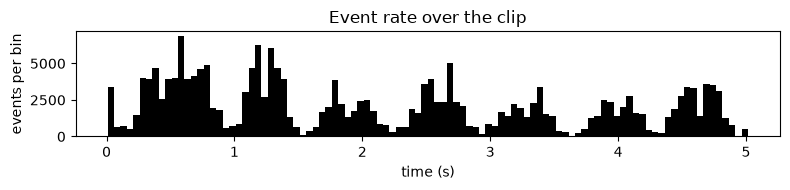

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 2))
ax.hist(events["t"] / 1e6, bins=100, color="black")
ax.set_xlabel("time (s)")
ax.set_ylabel("events per bin")
ax.set_title("Events over the clip")
plt.tight_layout()
plt.show()

## Step 2 — Wire events into an SNN

The next stage keeps the same primitive, but in software. The *leaky
integrate-and-fire* (LIF) neuron of practical SNNs is the direct
counterpart of a DVS pixel: a membrane potential $v$ leaks toward a
rest value, jumps whenever an input spike arrives, and emits a spike
of its own when it crosses a threshold:

$$\tau_m \frac{dv}{dt} = (v_\mathrm{rest} - v) + R\,I(t), \qquad \text{spike if } v \ge v_\mathrm{th}.$$

The network has two populations:

1. **Input layer** — one neuron per pixel, driven directly by the
   events from Step 1.
2. **Integrator** — 8 LIF neurons, each listening to a random ~2% of
   pixels through weak excitatory synapses.

The integrator's job is to sum evidence over a short time window (`tau_m
= 10 ms`) and emit its own spike whenever enough pixel activity arrives
close together in time. Between motions the whole network is silent,
because there is nothing to integrate; the events pass from sensor to
network without ever being flattened into a frame.

In [3]:
from brian2 import (
    SpikeGeneratorGroup, NeuronGroup, Synapses, SpikeMonitor,
    run, mV, ms, us, second,
)

# Flatten (x, y) into a single input neuron index. Brian2 sorts the
# spike times internally, so the events can go in as-is.
idx = events["y"].astype(int) * 128 + events["x"].astype(int)
pixels = SpikeGeneratorGroup(128 * 128, idx, events["t"] * us)

eqs = "dv/dt = (v_rest - v) / tau_m : volt"

integrator = NeuronGroup(
    N=8, model=eqs,
    threshold="v > v_th", reset="v = v_rest",
    method="exact",
    namespace={"v_rest": -70*mV, "v_th": -58*mV, "tau_m": 10*ms},
)
integrator.v = -70*mV

S = Synapses(pixels, integrator, on_pre="v_post += 0.5*mV")
S.connect(p=0.02)  # each integrator listens to ~2% of pixels

print("network wired.")

network wired.


## Step 3 — Run it and see the integrator track motion

In [4]:
M = SpikeMonitor(integrator)
run(events["t"].max() * us)

print(f"integrator spikes: {M.num_spikes}")
print(f"(vs {len(events):,} input events — a "
      f"{len(events) / max(M.num_spikes, 1):,.0f}× compression)")

integrator spikes: 247
(vs 209,094 input events — a 847× compression)


### Sensor rate vs. integrator rate

The top panel is the raw event rate — pixel events per 100 ms bin, one
hump per swing of the hands.

The bottom panel is the integrator's own spike count over the same
bins. It never saw a frame or did a dense matrix multiply, yet the two
curves rise and fall together, with roughly a thousand times fewer
spikes than events on the wire.

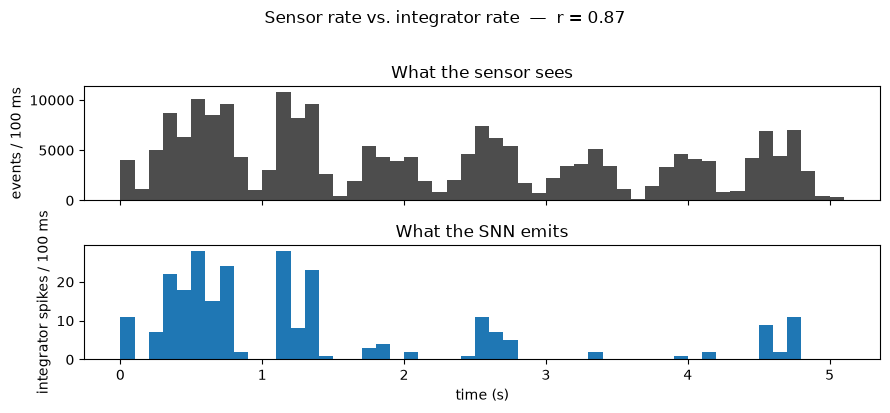

In [5]:
import matplotlib.pyplot as plt

t_end = events["t"].max() / 1e6
bins = np.arange(0, t_end + 0.1, 0.1)

event_hist, _ = np.histogram(events["t"] / 1e6, bins=bins)
int_hist, _   = np.histogram(np.asarray(M.t / second), bins=bins)
centers = 0.5 * (bins[:-1] + bins[1:])

fig, axes = plt.subplots(2, 1, figsize=(9, 4), sharex=True)

axes[0].bar(centers, event_hist, width=0.1, color="0.3", align="center")
axes[0].set_ylabel("events per 100 ms")
axes[0].set_title("What the camera saw")

axes[1].bar(centers, int_hist, width=0.1, color="C0", align="center")
axes[1].set_ylabel("spikes per 100 ms")
axes[1].set_xlabel("time (s)")
axes[1].set_title("What the network said")

r = np.corrcoef(event_hist, int_hist)[0, 1]
fig.suptitle(f"Input events vs. output spikes  —  r = {r:.2f}", y=1.02)

plt.tight_layout()
plt.savefig("sensor_vs_integrator.png", dpi=160, bbox_inches="tight")
plt.show()

## What to try next

- **Split ON and OFF.** Route positive-polarity events (`events["p"] == 1`) and negative-polarity events (`events["p"] == 0`) into two integrator pools with opposing readouts. The pair becomes a crude direction-of-motion detector.
- **Give the integrator spatial structure.** Instead of random fan-in from all pixels, wire each of the 8 integrator neurons to a different image quadrant. Now the network can tell you *where* something moved.
- **Close the loop.** Drive an output actuator (a servo, an LED, a print statement) from the integrator spikes. The whole perception→action pathway is then event-driven, end to end.
- **Swap the event source.** Anything that emits `(x, y, t, p)` tuples plugs into Step 2 unchanged: a heavier simulator like [v2e](https://github.com/SensorsINI/v2e) or [ESIM](https://github.com/uzh-rpg/rpg_esim), or a real event camera — AEDAT/DVS/Metavision recordings all live behind loaders like `dv_processing` or `metavision-sdk`.